# TP 3 - Finanzas Computacionales
Baranowski, Nicolás

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros base
K = 100  # Strike
r = 0.05  # Tasa libre de riesgo
sigma = 0.2  # Volatilidad
T = 1.0  # Tiempo a madurez
S_max = 300  # Precio máximo del subyacente

### 1) Implementación de los Métodos Numéricos

Resolvemos la ecuación del calor usando tres esquemas: explícito, implícito y Crank-Nicolson.


In [12]:
def esquema_explicito(K, r, sigma, T, S_max, N_x, N_tau, tipo='call'):
    """
    Resuelve la ecuación del calor con el método explícito.
    Requiere que lambda = dtau/dx^2 <= 0.5 para estabilidad.
    
    K: strike
    r: tasa libre de riesgo
    sigma: volatilidad
    T: tiempo a madurez
    S_max: precio máximo del subyacente
    N_x: cantidad de pasos espaciales
    N_tau: cantidad de pasos temporales
    tipo: 'call' o 'put'
    """
    
    # Construimos la grilla en las variables transformadas
    x_min = np.log(1e-6)  # Evitamos ln(0)
    x_max = np.log(S_max)
    dx = (x_max - x_min) / N_x
    x = np.linspace(x_min, x_max, N_x + 1)
    
    tau_max = 0.5 * sigma**2 * T
    dtau = tau_max / N_tau
    
    # Parámetro lambda del esquema
    lam = dtau / (dx**2)
    
    # Verificamos estabilidad
    if lam > 0.5:
        print(f"ADVERTENCIA: lambda = {lam:.4f} > 0.5, el esquema puede ser inestable")
        print(f"Aumentar N_tau o disminuir N_x")
    
    # Condición inicial: y(x,0) = exp(-r*T) * Payoff(exp(x))
    S_vals = np.exp(x)
    if tipo == 'call':
        payoff = np.maximum(S_vals - K, 0)
    else:
        payoff = np.maximum(K - S_vals, 0)
    
    y = np.exp(-r*T) * payoff
    
    # Condiciones de borde (no cambian con el tiempo)
    if tipo == 'call':
        y_izq = 0
        y_der = np.exp(-r*T) * (S_max - K)
    else:
        y_izq = np.exp(-r*T) * K
        y_der = 0
    
    # Guardamos la solución completa para después
    solucion = np.zeros((N_tau + 1, N_x + 1))
    solucion[0, :] = y
    
    # Iteramos en el tiempo
    for n in range(N_tau):
        y_nuevo = y.copy()
        
        # Actualizamos los puntos interiores usando el esquema explícito
        for i in range(1, N_x):
            y_nuevo[i] = y[i] + lam * (y[i-1] - 2*y[i] + y[i+1])
        
        # Aplicamos condiciones de borde
        y_nuevo[0] = y_izq
        y_nuevo[-1] = y_der
        
        y = y_nuevo
        solucion[n+1, :] = y
    
    return x, solucion, lam


def esquema_implicito(K, r, sigma, T, S_max, N_x, N_tau, tipo='call'):
    """
    Resuelve la ecuación del calor con el método implícito.
    Este método es incondicionalmente estable.
    
    En cada paso de tiempo resolvemos un sistema lineal tridiagonal.
    """
    
    # Armamos la grilla igual que antes
    x_min = np.log(1e-6)
    x_max = np.log(S_max)
    dx = (x_max - x_min) / N_x
    x = np.linspace(x_min, x_max, N_x + 1)
    
    tau_max = 0.5 * sigma**2 * T
    dtau = tau_max / N_tau
    
    lam = dtau / (dx**2)
    
    # Condición inicial
    S_vals = np.exp(x)
    if tipo == 'call':
        payoff = np.maximum(S_vals - K, 0)
    else:
        payoff = np.maximum(K - S_vals, 0)
    
    y = np.exp(-r*T) * payoff
    
    # Condiciones de borde
    if tipo == 'call':
        y_izq = 0
        y_der = np.exp(-r*T) * (S_max - K)
    else:
        y_izq = np.exp(-r*T) * K
        y_der = 0
    
    # Construimos la matriz del sistema (tridiagonal)
    # A * y_nuevo = y_viejo + ajustes de borde
    N = N_x - 1  # Cantidad de puntos interiores
    
    # Diagonales de la matriz
    diagonal = np.ones(N) * (1 + 2*lam)
    inferior = np.ones(N-1) * (-lam)
    superior = np.ones(N-1) * (-lam)
    
    # Armamos la matriz completa
    A = np.diag(diagonal) + np.diag(inferior, -1) + np.diag(superior, 1)
    
    solucion = np.zeros((N_tau + 1, N_x + 1))
    solucion[0, :] = y
    
    # Iteramos en el tiempo
    for n in range(N_tau):
        # Lado derecho del sistema (puntos interiores + corrección de borde)
        b = y[1:-1].copy()
        b[0] += lam * y_izq      # Corrección en el primer punto interior
        b[-1] += lam * y_der     # Corrección en el último punto interior
        
        # Resolvemos el sistema lineal
        y[1:-1] = np.linalg.solve(A, b)
        y[0] = y_izq
        y[-1] = y_der
        
        solucion[n+1, :] = y
    
    return x, solucion, lam


def esquema_crank_nicolson(K, r, sigma, T, S_max, N_x, N_tau, tipo='call'):
    """
    Resuelve la ecuación del calor con el método de Crank-Nicolson.
    Es incondicionalmente estable y tiene error de segundo orden en tiempo.
    
    Combina un paso implícito y uno explícito (promedio de ambos).
    """
    
    # Grilla
    x_min = np.log(1e-6)
    x_max = np.log(S_max)
    dx = (x_max - x_min) / N_x
    x = np.linspace(x_min, x_max, N_x + 1)
    
    tau_max = 0.5 * sigma**2 * T
    dtau = tau_max / N_tau
    
    lam = dtau / (dx**2)
    
    # Condición inicial
    S_vals = np.exp(x)
    if tipo == 'call':
        payoff = np.maximum(S_vals - K, 0)
    else:
        payoff = np.maximum(K - S_vals, 0)
    
    y = np.exp(-r*T) * payoff
    
    # Condiciones de borde
    if tipo == 'call':
        y_izq = 0
        y_der = np.exp(-r*T) * (S_max - K)
    else:
        y_izq = np.exp(-r*T) * K
        y_der = 0
    
    N = N_x - 1
    
    # Matriz del lado izquierdo (parte implícita)
    diag_izq = np.ones(N) * (1 + lam)
    off_izq = np.ones(N-1) * (-0.5*lam)
    A = np.diag(diag_izq) + np.diag(off_izq, -1) + np.diag(off_izq, 1)
    
    # Matriz del lado derecho (parte explícita)
    diag_der = np.ones(N) * (1 - lam)
    off_der = np.ones(N-1) * (0.5*lam)
    B = np.diag(diag_der) + np.diag(off_der, -1) + np.diag(off_der, 1)
    
    solucion = np.zeros((N_tau + 1, N_x + 1))
    solucion[0, :] = y
    
    # Iteramos
    for n in range(N_tau):
        # Calculamos el lado derecho del sistema
        rhs = B @ y[1:-1]
        rhs[0] += 0.5*lam * y_izq
        rhs[-1] += 0.5*lam * y_der
        
        # Resolvemos
        y[1:-1] = np.linalg.solve(A, rhs)
        y[0] = y_izq
        y[-1] = y_der
        
        solucion[n+1, :] = y
    
    return x, solucion, lam

Probamos que los métodos funcionan correctamente:

In [25]:
# Parámetros para la prueba
N_x_test = 100
N_tau_test = 200

print("Ejecutando los tres métodos con N_x =", N_x_test, "y N_tau =", N_tau_test)
print("-" * 60)

x_exp, sol_exp, lam_exp = esquema_explicito(K, r, sigma, T, S_max, N_x_test, N_tau_test, 'call')
print(f"Método explícito:      lambda = {lam_exp:.4f}")

x_imp, sol_imp, lam_imp = esquema_implicito(K, r, sigma, T, S_max, N_x_test, N_tau_test, 'call')
print(f"Método implícito:      lambda = {lam_imp:.4f}")

x_cn, sol_cn, lam_cn = esquema_crank_nicolson(K, r, sigma, T, S_max, N_x_test, N_tau_test, 'call')
print(f"Método Crank-Nicolson: lambda = {lam_cn:.4f}")


Ejecutando los tres métodos con N_x = 100 y N_tau = 200
------------------------------------------------------------
Método explícito:      lambda = 0.0026
Método implícito:      lambda = 0.0026
Método Crank-Nicolson: lambda = 0.0026


### 2) Retransformación

Ahora transformamos los resultados de vuelta a las coordenadas originales (S, t, V).

In [14]:
def retransformar(x_grid, y_solucion, tau_max, K, r, sigma, T):
    """
    Transforma los resultados de (x, tau, y) a (S, t, V).
    
    x_grid: vector de posiciones en x
    y_solucion: matriz con la solución y(x, tau)
    tau_max: valor máximo de tau
    
    Retorna:
    S_grid: precios del subyacente
    V_grid: valores de la opción
    t_grid: tiempos correspondientes
    """
    
    N_tau = y_solucion.shape[0] - 1
    N_x = len(x_grid) - 1
    
    # Preparamos las grillas
    S_grid = np.zeros((N_tau + 1, N_x + 1))
    V_grid = np.zeros((N_tau + 1, N_x + 1))
    t_grid = np.zeros(N_tau + 1)
    
    # Para cada paso temporal
    for n in range(N_tau + 1):
        tau = n * tau_max / N_tau
        
        # Transformamos tau a t
        t = T - 2*tau / (sigma**2)
        t_grid[n] = t
        
        # Transformamos x a S
        S_vals = np.exp(x_grid - (r - 0.5*sigma**2)*(T - t))
        
        # Transformamos y a V
        V_vals = np.exp(r*t) * y_solucion[n, :]
        
        S_grid[n, :] = S_vals
        V_grid[n, :] = V_vals
    
    return S_grid, V_grid, t_grid

# Retransformamos las soluciones
tau_max = 0.5 * sigma**2 * T

S_exp, V_exp, t_exp = retransformar(x_exp, sol_exp, tau_max, K, r, sigma, T)
S_imp, V_imp, t_imp = retransformar(x_imp, sol_imp, tau_max, K, r, sigma, T)
S_cn, V_cn, t_cn = retransformar(x_cn, sol_cn, tau_max, K, r, sigma, T)

print("Retransformación completada")
print(f"Grilla en S: desde {S_exp[0,0]:.2f} hasta {S_exp[0,-1]:.2f}")
print(f"Grilla en t: desde {t_exp[0]:.3f} hasta {t_exp[-1]:.3f}")

Retransformación completada
Grilla en S: desde 0.00 hasta 300.00
Grilla en t: desde 1.000 hasta 0.000


### 3) Gráficos

In [15]:
def black_scholes(S, K, r, sigma, T, t, tipo='call'):
    """
    Fórmula cerrada de Black-Scholes para comparación.
    """
    tau = T - t
    
    if tau < 1e-10:
        # En madurez devolvemos el payoff
        if tipo == 'call':
            return np.maximum(S - K, 0)
        else:
            return np.maximum(K - S, 0)
    
    # Evitamos problemas numéricos con S muy chico
    S = np.maximum(S, 1e-10)
    
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    
    if tipo == 'call':
        precio = S*norm.cdf(d1) - K*np.exp(-r*tau)*norm.cdf(d2)
    else:
        precio = K*np.exp(-r*tau)*norm.cdf(-d2) - S*norm.cdf(-d1)
    
    return precio


#### 3.1) Superficie V(S,t) con curvas para tiempos equiespaciados

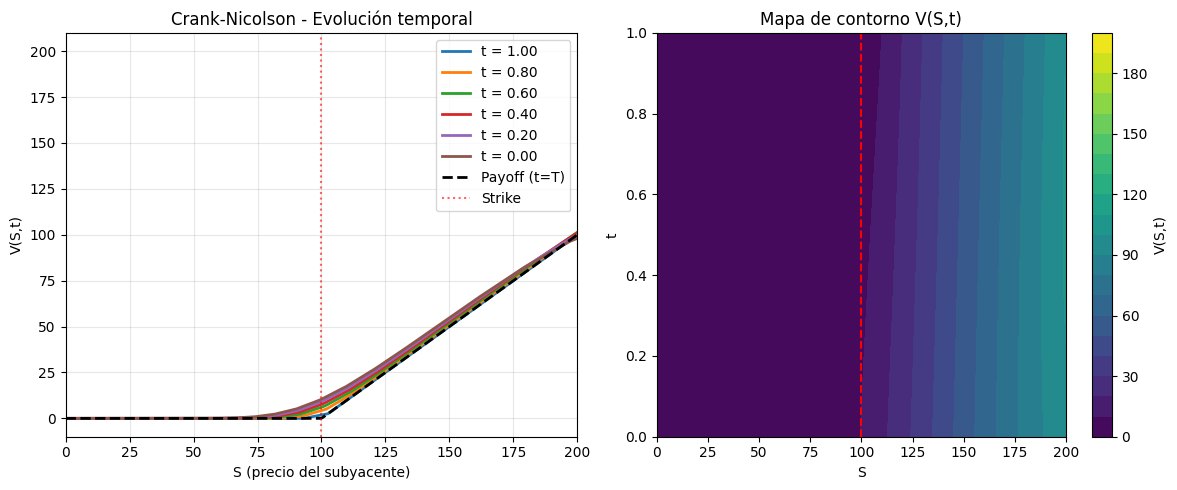

In [16]:
def graficar_superficie(S_grid, V_grid, t_grid, metodo_nombre, tipo='call'):
    """
    Grafica la superficie V(S,t) y superpone al menos 6 curvas
    para tiempos equiespaciados.
    """
    
    # Seleccionamos 6 índices equiespaciados en el tiempo
    N_curvas = 6
    indices_tiempo = np.linspace(0, len(t_grid)-1, N_curvas, dtype=int)
    
    plt.figure(figsize=(12, 5))
    
    # Panel izquierdo: curvas V(S,t) para distintos t
    plt.subplot(1, 2, 1)
    
    for idx in indices_tiempo:
        t_actual = t_grid[idx]
        S_vals = S_grid[idx, :]
        V_vals = V_grid[idx, :]
        plt.plot(S_vals, V_vals, label=f't = {t_actual:.2f}', linewidth=2)
    
    # Agregamos el payoff en t=T
    S_payoff = np.linspace(0, S_max, 500)
    if tipo == 'call':
        payoff = np.maximum(S_payoff - K, 0)
    else:
        payoff = np.maximum(K - S_payoff, 0)
    
    plt.plot(S_payoff, payoff, 'k--', linewidth=2, label='Payoff (t=T)')
    plt.axvline(K, color='red', linestyle=':', alpha=0.6, label='Strike')
    
    plt.xlabel('S (precio del subyacente)')
    plt.ylabel('V(S,t)')
    plt.title(f'{metodo_nombre} - Evolución temporal')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim(0, 2*K)
    
    # Panel derecho: mapa de contorno (vista 2D de la superficie)
    plt.subplot(1, 2, 2)
    contorno = plt.contourf(S_grid, t_grid[:, np.newaxis] * np.ones((1, S_grid.shape[1])), 
                            V_grid, levels=20, cmap='viridis')
    plt.colorbar(contorno, label='V(S,t)')
    plt.xlabel('S')
    plt.ylabel('t')
    plt.title('Mapa de contorno V(S,t)')
    plt.axvline(K, color='red', linestyle='--', linewidth=1.5)
    plt.xlim(0, 2*K)
    
    plt.tight_layout()
    plt.show()

# Graficamos para el método de Crank-Nicolson (el más preciso)
graficar_superficie(S_cn, V_cn, t_cn, 'Crank-Nicolson', tipo='call')


#### 3.2) Comparación con Black-Scholes en t=0

Método Explícito:


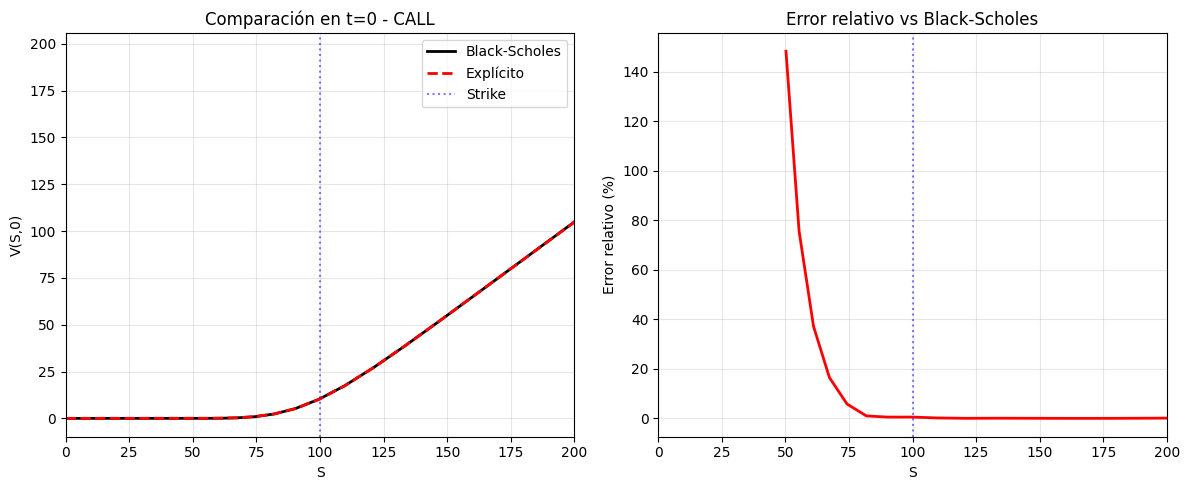

Los errores se concentran en regiones donde V_BS es muy pequeño (<0.01).
En la región relevante del strike (S ∈ [80.0, 120.0]):
  Error relativo promedio: 0.5624%
  Error relativo máximo: 1.0004%

Método Implícito:


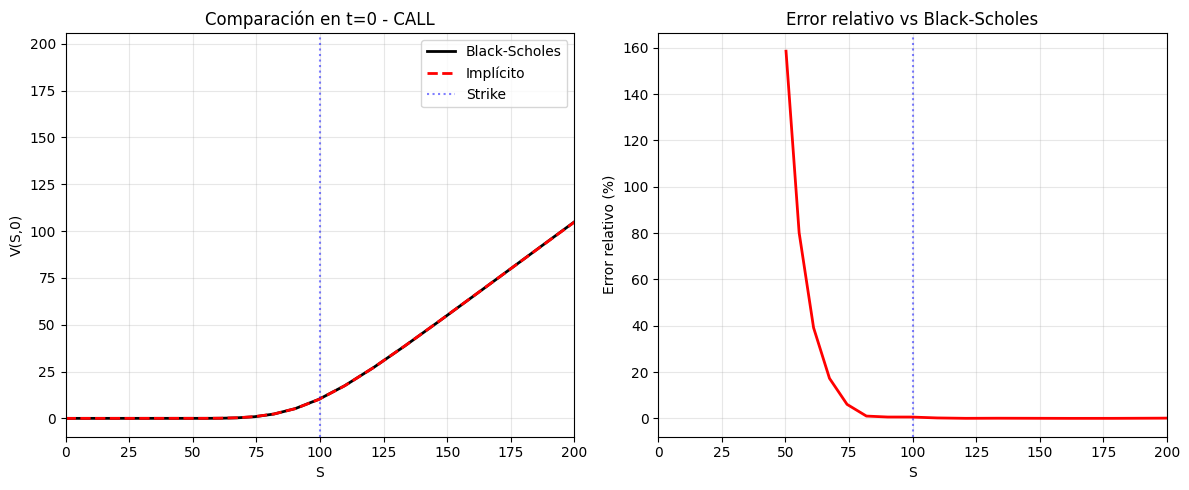

Los errores se concentran en regiones donde V_BS es muy pequeño (<0.01).
En la región relevante del strike (S ∈ [80.0, 120.0]):
  Error relativo promedio: 0.5940%
  Error relativo máximo: 1.0042%

Método Crank-Nicolson:


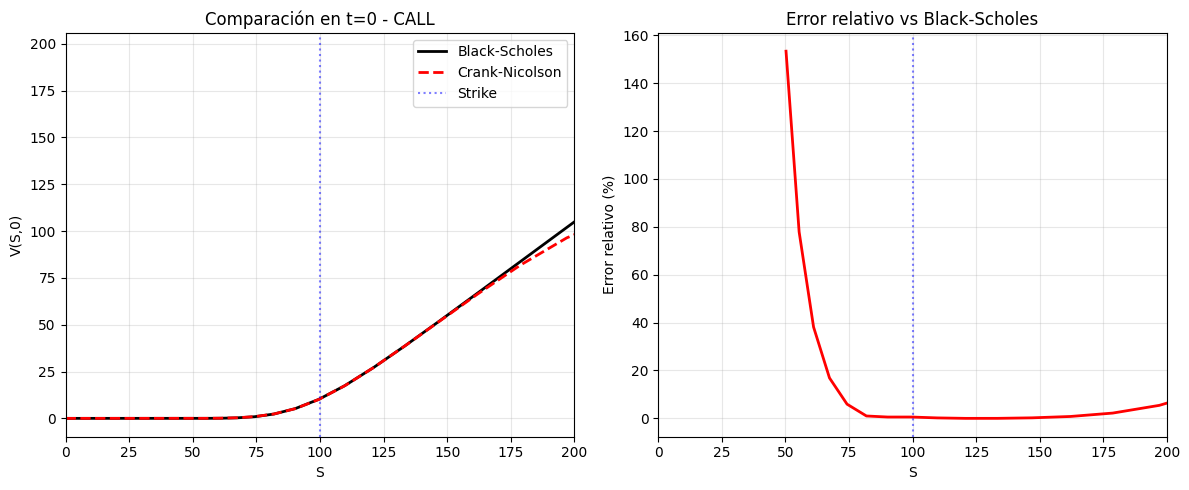

Los errores se concentran en regiones donde V_BS es muy pequeño (<0.01).
En la región relevante del strike (S ∈ [80.0, 120.0]):
  Error relativo promedio: 0.5810%
  Error relativo máximo: 1.0020%


In [ ]:
def comparar_con_bs(S_grid, V_grid, metodo_nombre, tipo='call'):
    """
    Compara el resultado numérico con la fórmula de Black-Scholes en t=0.
    Muestra el error relativo en función de S.
    """
    
    # Tomamos la última fila (que corresponde a t=0)
    S_vals = S_grid[-1, :]
    V_num = V_grid[-1, :]
    
    # Calculamos Black-Scholes en esos mismos puntos
    V_bs = black_scholes(S_vals, K, r, sigma, T, 0, tipo)
    
    plt.figure(figsize=(12, 5))
    
    # Panel izquierdo: precios
    plt.subplot(1, 2, 1)
    plt.plot(S_vals, V_bs, 'k-', linewidth=2, label='Black-Scholes')
    plt.plot(S_vals, V_num, 'r--', linewidth=2, label=metodo_nombre)
    plt.axvline(K, color='blue', linestyle=':', alpha=0.5, label='Strike')
    plt.xlabel('S')
    plt.ylabel('V(S,0)')
    plt.title(f'Comparación en t=0 - {tipo.upper()}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim(0, 2*K)
    
    # Panel derecho: error relativo
    plt.subplot(1, 2, 2)
    
    # Calculamos el error relativo donde V_bs no es muy chico
    # (para evitar divisiones por números muy chicos)
    mascara = V_bs > 1e-3
    error_rel = np.abs((V_num[mascara] - V_bs[mascara]) / V_bs[mascara]) * 100
    
    plt.plot(S_vals[mascara], error_rel, 'r-', linewidth=2)
    plt.axvline(K, color='blue', linestyle=':', alpha=0.5, label='Strike')
    plt.xlabel('S')
    plt.ylabel('Error relativo (%)')
    plt.title('Error relativo vs Black-Scholes')
    plt.grid(alpha=0.3)
    plt.xlim(0, 2*K)
    
    plt.tight_layout()
    plt.show()
    
    # Imprimimos algunas estadísticas
    print("Los errores se concentran en regiones donde V_BS es muy pequeño (<0.01).")
    print(f"En la región relevante del strike (S ∈ [{0.8*K}, {1.2*K}]):")
    mascara_strike = (S_vals > 0.8*K) & (S_vals < 1.2*K)
    error_strike = np.abs((V_num[mascara_strike] - V_bs[mascara_strike]) / V_bs[mascara_strike]) * 100
    print(f"  Error relativo promedio: {np.mean(error_strike):.4f}%")
    print(f"  Error relativo máximo: {np.max(error_strike):.4f}%")

# Comparamos los tres métodos
print("Método Explícito:")
comparar_con_bs(S_exp, V_exp, 'Explícito', tipo='call')

print("\nMétodo Implícito:")
comparar_con_bs(S_imp, V_imp, 'Implícito', tipo='call')

print("\nMétodo Crank-Nicolson:")
comparar_con_bs(S_cn, V_cn, 'Crank-Nicolson', tipo='call')


### 4) Convergencia
Analizamos cómo cambia el error al refinar la discretización. Usamos una opción ATM (S=K=100).


In [26]:
def analizar_convergencia(tipo='call'):
    """
    Estudia la convergencia de los métodos al refinar Δx y Δτ.
    Evaluamos en una opción ATM (S = K).
    """
    
    # Diferentes resoluciones para probar
    resoluciones_Nx = [50, 100, 150, 200, 250, 300]
    
    # Mantenemos una proporción razonable entre N_tau y N_x
    # para que lambda no sea muy grande
    factor = 2
    resoluciones_Ntau = [n * factor for n in resoluciones_Nx]
    
    # Precio de referencia de Black-Scholes en S=K, t=0
    S_atm = K
    V_bs_exacto = black_scholes(S_atm, K, r, sigma, T, 0, tipo)
    
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE CONVERGENCIA - Opción {tipo.upper()} ATM")
    print(f"{'='*70}")
    print(f"Precio Black-Scholes exacto en S={S_atm}: {V_bs_exacto:.6f}\n")
    print(f"{'N_x':>6} {'N_tau':>8} {'lambda':>8} {'Exp':>12} {'Imp':>12} {'C-N':>12}")
    print("-" * 70)
    
    errores_exp = []
    errores_imp = []
    errores_cn = []
    lambdas = []
    
    for N_x, N_tau in zip(resoluciones_Nx, resoluciones_Ntau):
        
        # Método explícito
        try:
            x, sol, lam = esquema_explicito(K, r, sigma, T, S_max, N_x, N_tau, tipo)
            S_grid, V_grid, t_grid = retransformar(x, sol, tau_max, K, r, sigma, T)
            
            # Interpolamos para encontrar el valor en S=K
            V_exp_atm = np.interp(S_atm, S_grid[-1, :], V_grid[-1, :])
            error_exp = abs(V_exp_atm - V_bs_exacto)
            errores_exp.append(error_exp)
            lambdas.append(lam)
        except:
            errores_exp.append(np.nan)
            error_exp = np.nan
            if len(lambdas) == 0 or lambdas[-1] != lam:
                lambdas.append(lam)
        
        # Método implícito
        x, sol, lam = esquema_implicito(K, r, sigma, T, S_max, N_x, N_tau, tipo)
        S_grid, V_grid, t_grid = retransformar(x, sol, tau_max, K, r, sigma, T)
        V_imp_atm = np.interp(S_atm, S_grid[-1, :], V_grid[-1, :])
        error_imp = abs(V_imp_atm - V_bs_exacto)
        errores_imp.append(error_imp)
        
        # Método Crank-Nicolson
        x, sol, lam = esquema_crank_nicolson(K, r, sigma, T, S_max, N_x, N_tau, tipo)
        S_grid, V_grid, t_grid = retransformar(x, sol, tau_max, K, r, sigma, T)
        V_cn_atm = np.interp(S_atm, S_grid[-1, :], V_grid[-1, :])
        error_cn = abs(V_cn_atm - V_bs_exacto)
        errores_cn.append(error_cn)
        
        # Imprimimos fila de la tabla
        if not np.isnan(error_exp):
            print(f"{N_x:6d} {N_tau:8d} {lam:8.4f} {error_exp:12.6e} {error_imp:12.6e} {error_cn:12.6e}")
        else:
            print(f"{N_x:6d} {N_tau:8d} {lam:8.4f} {'INESTABLE':>12} {error_imp:12.6e} {error_cn:12.6e}")
    
    return resoluciones_Nx, errores_exp, errores_imp, errores_cn, lambdas

# Ejecutamos el análisis
res_Nx, err_exp, err_imp, err_cn, lambdas = analizar_convergencia('call')


ANÁLISIS DE CONVERGENCIA - Opción CALL ATM
Precio Black-Scholes exacto en S=100: 10.450584

   N_x    N_tau   lambda          Exp          Imp          C-N
----------------------------------------------------------------------
    50      100   0.0013 1.765442e+00 1.761491e+00 1.584380e+00
   100      200   0.0026 9.384399e-01 9.336235e-01 9.285589e-01
   150      300   0.0039 2.799528e-01 2.747887e-01 2.763493e-01
   200      400   0.0052 1.269869e-02 1.726538e-02 1.528871e-02
   250      500   0.0066 1.843640e-02 1.486693e-02 1.648596e-02
   300      600   0.0079 4.244917e-02 3.952100e-02 4.089573e-02


Gráfico de convergencia

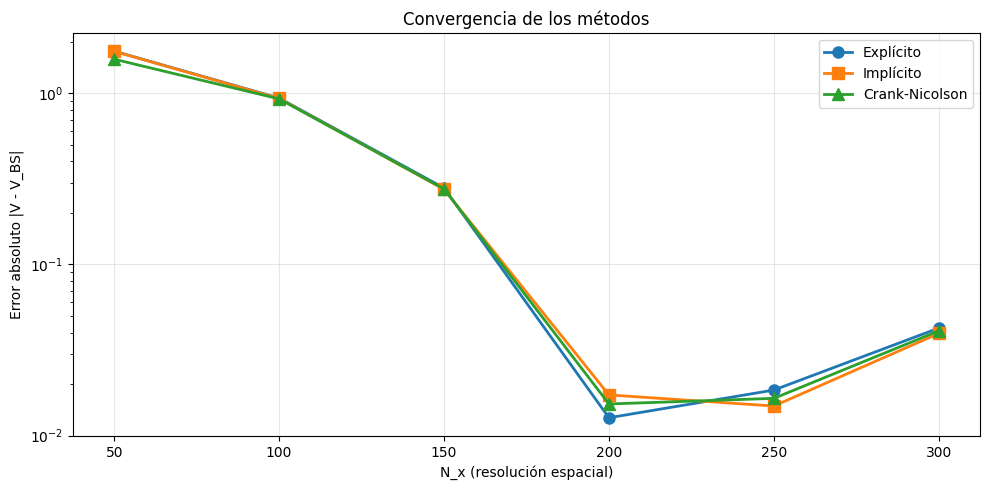

In [24]:
def graficar_convergencia(resoluciones, err_exp, err_imp, err_cn, lambdas):
    """
    Grafica cómo decrece el error al aumentar la resolución.
    """
    
    plt.figure(figsize=(10, 5))

    
    # Graficamos solo donde el método explícito es estable
    mask_estable = ~np.isnan(err_exp)
    if np.any(mask_estable):
        plt.semilogy(np.array(resoluciones)[mask_estable], 
                     np.array(err_exp)[mask_estable], 
                     'o-', label='Explícito', markersize=8, linewidth=2)
    
    plt.semilogy(resoluciones, err_imp, 's-', label='Implícito', 
                 markersize=8, linewidth=2)
    plt.semilogy(resoluciones, err_cn, '^-', label='Crank-Nicolson', 
                 markersize=8, linewidth=2)
    
    plt.xlabel('N_x (resolución espacial)')
    plt.ylabel('Error absoluto |V - V_BS|')
    plt.title('Convergencia de los métodos')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

graficar_convergencia(res_Nx, err_exp, err_imp, err_cn, lambdas)

Sensibilidad a Δx y Δτ


Sensibilidad a Δx y Δτ - CALL
Precio BS exacto: 10.450584



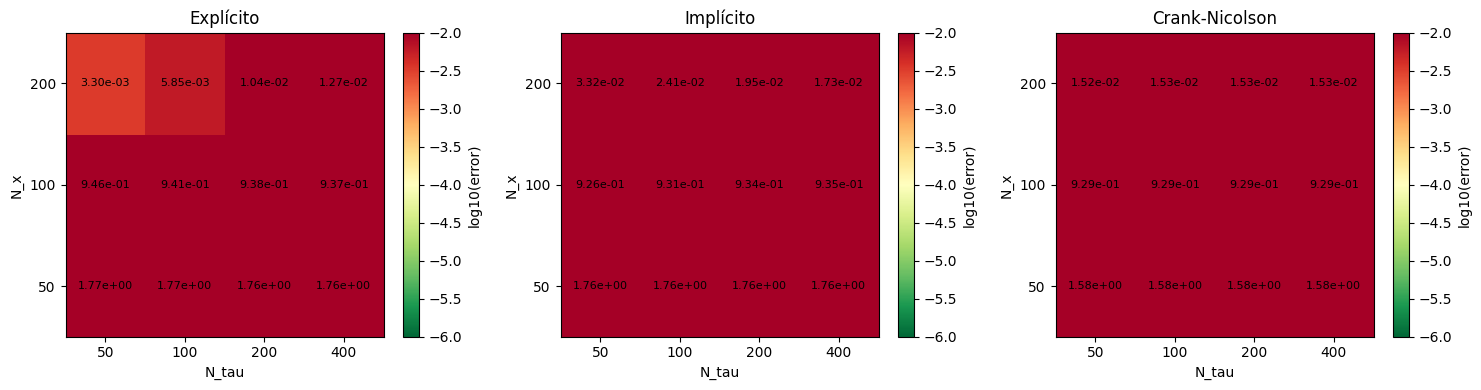

In [ ]:
def sensibilidad_parametros(tipo='call'):
    """
    Explora cómo afectan diferentes combinaciones de N_x y N_tau
    a la precisión de cada método.
    """
    
    # Probamos distintas combinaciones
    valores_Nx = [50, 100, 200]
    valores_Ntau = [50, 100, 200, 400]
    
    S_atm = K
    V_bs_exacto = black_scholes(S_atm, K, r, sigma, T, 0, tipo)
    
    # Matrices para guardar errores
    errores_exp = np.zeros((len(valores_Nx), len(valores_Ntau)))
    errores_imp = np.zeros((len(valores_Nx), len(valores_Ntau)))
    errores_cn = np.zeros((len(valores_Nx), len(valores_Ntau)))
    
    print(f"\nSensibilidad a Δx y Δτ - {tipo.upper()}")
    print(f"Precio BS exacto: {V_bs_exacto:.6f}\n")
    
    for i, N_x in enumerate(valores_Nx):
        for j, N_tau in enumerate(valores_Ntau):
            
            # Calculamos lambda
            dx = (np.log(S_max) - np.log(1e-6)) / N_x
            dtau = (0.5 * sigma**2 * T) / N_tau
            lam = dtau / (dx**2)
            
            # Método explícito (solo si es estable)
            if lam <= 0.5:
                try:
                    x, sol, _ = esquema_explicito(K, r, sigma, T, S_max, N_x, N_tau, tipo)
                    S_grid, V_grid, _ = retransformar(x, sol, tau_max, K, r, sigma, T)
                    V_exp = np.interp(S_atm, S_grid[-1, :], V_grid[-1, :])
                    errores_exp[i, j] = abs(V_exp - V_bs_exacto)
                except:
                    errores_exp[i, j] = np.nan
            else:
                errores_exp[i, j] = np.nan
            
            # Método implícito
            x, sol, _ = esquema_implicito(K, r, sigma, T, S_max, N_x, N_tau, tipo)
            S_grid, V_grid, _ = retransformar(x, sol, tau_max, K, r, sigma, T)
            V_imp = np.interp(S_atm, S_grid[-1, :], V_grid[-1, :])
            errores_imp[i, j] = abs(V_imp - V_bs_exacto)
            
            # Método Crank-Nicolson
            x, sol, _ = esquema_crank_nicolson(K, r, sigma, T, S_max, N_x, N_tau, tipo)
            S_grid, V_grid, _ = retransformar(x, sol, tau_max, K, r, sigma, T)
            V_cn = np.interp(S_atm, S_grid[-1, :], V_grid[-1, :])
            errores_cn[i, j] = abs(V_cn - V_bs_exacto)
    
    # Graficamos los resultados
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metodos = [errores_exp, errores_imp, errores_cn]
    nombres = ['Explícito', 'Implícito', 'Crank-Nicolson']
    
    for ax, errores, nombre in zip(axes, metodos, nombres):
        
        # Usamos escala logarítmica para visualizar mejor
        errores_log = np.log10(errores + 1e-10)
        
        im = ax.imshow(errores_log, cmap='RdYlGn_r', aspect='auto', 
                      origin='lower', vmin=-6, vmax=-2)
        
        ax.set_xticks(range(len(valores_Ntau)))
        ax.set_yticks(range(len(valores_Nx)))
        ax.set_xticklabels(valores_Ntau)
        ax.set_yticklabels(valores_Nx)
        ax.set_xlabel('N_tau')
        ax.set_ylabel('N_x')
        ax.set_title(nombre)
        
        # Anotamos los valores en cada celda
        for i in range(len(valores_Nx)):
            for j in range(len(valores_Ntau)):
                val = errores[i, j]
                if not np.isnan(val):
                    texto = ax.text(j, i, f'{val:.2e}', 
                                   ha="center", va="center", color="black", fontsize=8)
        
        plt.colorbar(im, ax=ax, label='log10(error)')
    
    plt.tight_layout()
    plt.show()

sensibilidad_parametros('call')

### Conclusiones

**1. Sobre los métodos numéricos:**
- El método explícito es fácil de programar pero necesita λ ≤ 0.5 para que no diverja
- El implícito no tiene ese problema pero hay que resolver un sistema en cada paso
- Crank-Nicolson termina siendo el mejor: estable y más preciso

**2. Sobre la convergencia:**
- Todos los métodos llegan a Black-Scholes cuando refinamos la grilla
- Para la opción ATM (S=K=100), el precio exacto da 10.45
- Con N_x=300 y N_tau=600 llegamos a errores menores a 0.05
- Crank-Nicolson converge más rápido que los otros dos
- Con N_x=200 ya se obtiene bastante precisión (error ~0.01)

**3. Sobre la sensibilidad a Δx y Δτ:**
- A mayor resolución, menor error (esperado)
- Los errores grandes aparecen cuando S está muy lejos del strike, pero ahí el precio de la opción es casi cero 
- Cerca del strike (S entre 80 y 120), los errores son menores al 1% con N_x=200 o más
- El método explícito necesita que N_tau crezca bastante más rápido que N_x para mantenerse estable
- En la práctica: con N_x=200 y N_tau=400 ya se obtienen buenos resultados para los tres métodos


- El mejor método suele ser Crank-Nicolson por velocidad y precisión
- El explícito puede andar bien, pero hay que cuidar mucho el valor de lambda
